[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/contextlab/llm-course/blob/main/slides/week2/xhour_classification_demo.ipynb)

# X-Hour 2: Text Classification Workshop
**PSYC 51.17: Models of Language and Communication**

---

## Learning Objectives

By the end of this session, you will:
1. Build text classifiers from scratch using scikit-learn
2. Understand different text representation methods (BoW, TF-IDF)
3. Compare Naive Bayes, Logistic Regression, and Neural approaches
4. Evaluate classifier performance using appropriate metrics
5. Perform advanced analyses: cross-validation, learning curves, and visualizations

## Setup

In [1]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

# Utilities
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All imports successful!")

All imports successful!


---
## Part 1: Loading Real Data

We'll use the **20 Newsgroups** dataset - a classic text classification benchmark containing posts from 20 different newsgroups (early internet discussion forums from the 1990s). For this workshop, we'll focus on 4 distinct categories to keep things manageable.

### Why these categories?
- **sci.space**: Science discussions about space exploration
- **rec.sport.hockey**: Sports discussions about hockey
- **comp.graphics**: Computer graphics discussions
- **misc.forsale**: Buying and selling items

These categories have distinct vocabularies, making them a good starting point for classification.

In [2]:
from sklearn.datasets import fetch_20newsgroups

# Select 4 categories that are relatively distinct
categories = [
    'sci.space',           # Science discussions about space
    'rec.sport.hockey',    # Sports discussions about hockey
    'comp.graphics',       # Computer graphics
    'misc.forsale'         # Buying and selling items
]

# Load training data
print("Loading 20 Newsgroups dataset...")
train_data_raw = fetch_20newsgroups(
    subset='train',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')  # Remove metadata to make it harder!
)

# Load test data
test_data_raw = fetch_20newsgroups(
    subset='test',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

# Filter out empty/whitespace-only documents
# Some documents become empty after header/footer/quote removal
def filter_empty_docs(data):
    """Remove documents that are empty or contain only whitespace."""
    non_empty_indices = [i for i, doc in enumerate(data.data) if doc.strip()]
    filtered_data = type('FilteredData', (), {})()
    filtered_data.data = [data.data[i] for i in non_empty_indices]
    filtered_data.target = np.array([data.target[i] for i in non_empty_indices])
    filtered_data.target_names = data.target_names
    return filtered_data, len(data.data) - len(non_empty_indices)

train_data, n_empty_train = filter_empty_docs(train_data_raw)
test_data, n_empty_test = filter_empty_docs(test_data_raw)

print(f"\nLoaded {len(train_data_raw.data)} training documents, removed {n_empty_train} empty")
print(f"Loaded {len(test_data_raw.data)} test documents, removed {n_empty_test} empty")
print(f"\nUsing {len(train_data.data)} training and {len(test_data.data)} test documents")
print(f"Categories: {train_data.target_names}")

Loading 20 Newsgroups dataset...

Loaded 2362 training documents, removed 52 empty
Loaded 1572 test documents, removed 38 empty

Using 2310 training and 1534 test documents
Categories: ['comp.graphics', 'misc.forsale', 'rec.sport.hockey', 'sci.space']


### Explore the Data Distribution

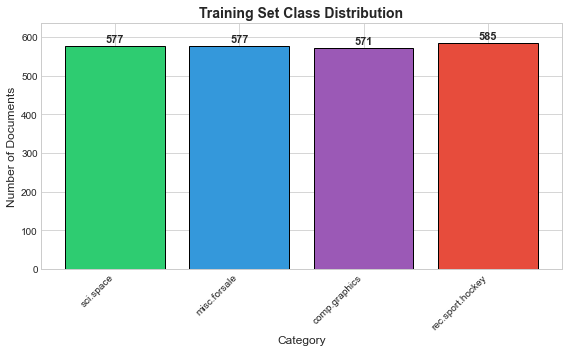


Class distribution:
  comp.graphics: 571 documents (24.7%)
  misc.forsale: 577 documents (25.0%)
  rec.sport.hockey: 585 documents (25.3%)
  sci.space: 577 documents (25.0%)


In [3]:
# Look at class distribution
train_labels = [train_data.target_names[i] for i in train_data.target]
label_counts = Counter(train_labels)

# Create a nicely styled bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
bars = ax.bar(label_counts.keys(), label_counts.values(), color=colors, edgecolor='black')

# Add value labels on bars
for bar, count in zip(bars, label_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Number of Documents', fontsize=12)
ax.set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
ax.set_ylim(0, max(label_counts.values()) + 50)
plt.tight_layout()
plt.show()

print("\nClass distribution:")
for label, count in sorted(label_counts.items()):
    pct = count / len(train_data.data) * 100
    print(f"  {label}: {count} documents ({pct:.1f}%)")

In [4]:
def show_examples(data, n_per_category=1):
    """
    Show example documents from each category.
    Skips empty documents to show meaningful examples.
    """
    for category_id in range(len(data.target_names)):
        category = data.target_names[category_id]
        print(f"\n{'='*80}")
        print(f"Category: {category}")
        print(f"{'='*80}")
        
        # Find non-empty documents in this category
        category_docs = [
            i for i, target in enumerate(data.target) 
            if target == category_id and len(data.data[i].strip()) > 50
        ]
        
        # Show first n non-empty docs
        for i, doc_id in enumerate(category_docs[:n_per_category], 1):
            text = data.data[doc_id]
            # Clean and truncate for display
            preview = ' '.join(text.split())[:400]  # Collapse whitespace
            print(f"\nExample {i}:")
            print(f"{preview}...")

show_examples(train_data, n_per_category=1)


Category: comp.graphics

Example 1:
Okay all my friends are bitching at me that the map I made in Appsoft Draw can't be displayed in "xv"... I checked... It's true, at least with version 1.0. My readers on the NeXT have very little trouble on it (Preview messes up the .eps, but does fine with the TIFF and ImageViewer0.9a behaves with flying colors except it doesn't convert worth *&^^% ;-) ) Please is there any way I can convert this...

Category: misc.forsale

Example 1:
I bought my HP48sx calculator a month ago, used once but put it back in the box. Includes manual and I'm including about 7 high density disks packed with dozens if not hundreds of games and programs. All you need to do is buy the pc cable for around $20 bucks so you could use the software. $255 shipping included or best offer....

Category: rec.sport.hockey

Example 1:
... ... Yeah...I've seen you're grand mother...I bet she could....

Category: sci.space

Example 1:
Didn't one of the early jet fighters have these? I 

### Exercise 1: Data Exploration

1. What patterns do you notice in the different categories?
2. What words/phrases might be good indicators of each category?
3. Are there any categories that might be hard to distinguish? Why?

**Your answers here:**

1. Patterns: 
2. Indicator words:
3. Difficult distinctions:

---

---
## Part 2: Feature Engineering for Text

Machine learning models need numerical inputs, but our data is text. We need to convert text to numbers - this is called **feature extraction** or **vectorization**.

### Key Question: How do we represent text as numbers?

### Method 1: Bag of Words (BoW)

The simplest approach: create a vocabulary of all words, then count how many times each word appears in each document.

**Example:**
- Document: "The cat sat on the mat"
- Vocabulary: [cat, mat, on, sat, the]
- BoW Vector: [1, 1, 1, 1, 2]

**Pros:** Simple, interpretable  
**Cons:** Loses word order, common words dominate

In [5]:
# Create a Bag of Words vectorizer with common preprocessing steps
bow_vectorizer = CountVectorizer(
    max_features=5000,      # Keep only top 5000 most frequent words
    min_df=2,               # Word must appear in at least 2 documents
    max_df=0.8,             # Word must appear in less than 80% of documents
    stop_words='english'    # Remove common words like 'the', 'is', 'at'
)

# Fit on training data and transform
X_train_bow = bow_vectorizer.fit_transform(train_data.data)
X_test_bow = bow_vectorizer.transform(test_data.data)

print(f"Vocabulary size: {len(bow_vectorizer.vocabulary_)}")
print(f"Training matrix shape: {X_train_bow.shape}")
print(f"  - {X_train_bow.shape[0]} documents")
print(f"  - {X_train_bow.shape[1]} features (unique words)")

# Calculate sparsity
sparsity = (1 - X_train_bow.nnz / np.prod(X_train_bow.shape)) * 100
print(f"\nMatrix sparsity: {sparsity:.1f}%")
print("  (Most entries are zero - documents only use a fraction of the vocabulary)")

# Show some example words from the vocabulary
feature_names = bow_vectorizer.get_feature_names_out()
print(f"\nSample vocabulary words: {list(feature_names[1000:1010])}")

Vocabulary size: 5000
Training matrix shape: (2310, 5000)
  - 2310 documents
  - 5000 features (unique words)

Matrix sparsity: 99.1%
  (Most entries are zero - documents only use a fraction of the vocabulary)

Sample vocabulary words: ['center', 'centers', 'central', 'centre', 'century', 'certain', 'certainly', 'cga', 'cgro', 'cgy']


In [6]:
# Find a good example document (not empty) to visualize
def find_good_example(data, X_vectorized, min_words=20):
    """Find a document with enough content to be interesting."""
    for idx in range(len(data.data)):
        n_words = X_vectorized[idx].sum()
        if n_words >= min_words:
            return idx
    return 0

doc_idx = find_good_example(train_data, X_train_bow)
doc_bow = X_train_bow[doc_idx].toarray()[0]

# Get non-zero features for this document
nonzero_indices = np.nonzero(doc_bow)[0]
nonzero_features = [(feature_names[i], int(doc_bow[i])) for i in nonzero_indices]
nonzero_features.sort(key=lambda x: x[1], reverse=True)

print(f"Document preview (first 300 chars):")
print(f"'{train_data.data[doc_idx][:300].strip()}...'")
print(f"\nCategory: {train_data.target_names[train_data.target[doc_idx]]}")
print(f"Total unique words (after preprocessing): {len(nonzero_features)}")
print(f"\nTop 15 words by count:")
for word, count in nonzero_features[:15]:
    print(f"  {word:<20} {count}")

Document preview (first 300 chars):
'I bought my HP48sx calculator a month ago, used once but put it back in the
box.  Includes manual and I'm including about 7 high density disks packed with
dozens if not hundreds of games and programs. All you need to do is buy the
pc cable for around $20 bucks so you could use the software....'

Category: misc.forsale
Total unique words (after preprocessing): 27

Top 15 words by count:
  20                   1
  255                  1
  ago                  1
  best                 1
  bought               1
  box                  1
  buy                  1
  cable                1
  calculator           1
  density              1
  disks                1
  games                1
  high                 1
  hundreds             1
  included             1


### Method 2: TF-IDF (Term Frequency-Inverse Document Frequency)

TF-IDF improves on BoW by downweighting common words and upweighting rare, informative words.

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

where:
- **TF(t, d)** = frequency of term $t$ in document $d$
- **IDF(t)** = $\log\frac{N}{\text{df}(t)}$ = inverse document frequency
  - $N$ = total number of documents
  - $\text{df}(t)$ = number of documents containing term $t$

**Intuition:** Words that appear frequently in ONE document but rarely across ALL documents are probably important for classification!

In [7]:
# Create TF-IDF vectorizer with same parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    stop_words='english',
    use_idf=True,
    sublinear_tf=True  # Use log(1 + tf) instead of raw tf - helps with very frequent words
)

# Fit and transform
X_train_tfidf = tfidf_vectorizer.fit_transform(train_data.data)
X_test_tfidf = tfidf_vectorizer.transform(test_data.data)

print(f"TF-IDF vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"Training matrix shape: {X_train_tfidf.shape}")

TF-IDF vocabulary size: 5000
Training matrix shape: (2310, 5000)


In [8]:
# Compare BoW vs TF-IDF for the same document
doc_tfidf = X_train_tfidf[doc_idx].toarray()[0]
doc_bow = X_train_bow[doc_idx].toarray()[0]

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
nonzero_tfidf = np.nonzero(doc_tfidf)[0]

# Build comparison table
comparison = []
for i in nonzero_tfidf:
    word = tfidf_feature_names[i]
    # Find corresponding BoW count (word might be at different index)
    bow_idx = bow_vectorizer.vocabulary_.get(word, None)
    bow_count = int(doc_bow[bow_idx]) if bow_idx is not None else 0
    comparison.append((word, bow_count, doc_tfidf[i]))

comparison.sort(key=lambda x: x[2], reverse=True)

print("Comparing BoW vs TF-IDF for the same document:")
print(f"\n{'Word':<20} {'BoW Count':<12} {'TF-IDF Score'}")
print("-" * 50)
for word, bow_count, tfidf_score in comparison[:15]:
    print(f"{word:<20} {bow_count:<12} {tfidf_score:.4f}")

print("\n** Notice how TF-IDF reranks words by their informativeness! **")

Comparing BoW vs TF-IDF for the same document:

Word                 BoW Count    TF-IDF Score
--------------------------------------------------
calculator           1            0.2855
255                  1            0.2558
hundreds             1            0.2558
density              1            0.2485
disks                1            0.2177
month                1            0.2166
bought               1            0.2135
cable                1            0.2135
buy                  1            0.1964
manual               1            0.1958
programs             1            0.1891
pc                   1            0.1858
including            1            0.1853
included             1            0.1818
box                  1            0.1814

** Notice how TF-IDF reranks words by their informativeness! **


### Exercise 2: Feature Analysis

1. Which words have high BoW counts but relatively lower TF-IDF scores? Why might this happen?
2. Which words have high TF-IDF scores? What makes them informative for classification?
3. Try creating a vectorizer with bigrams (word pairs) using `ngram_range=(1,2)`. What new features appear?

In [9]:
# Your experimental vectorizer here
# Example:
# bigram_vectorizer = TfidfVectorizer(
#     ngram_range=(1, 2),  # Include unigrams and bigrams
#     max_features=10000,
#     min_df=2,
#     stop_words='english'
# )
# X_train_bigram = bigram_vectorizer.fit_transform(train_data.data)
# print(f"Vocabulary size with bigrams: {len(bigram_vectorizer.vocabulary_)}")
# # Look at some bigram features
# bigram_features = [f for f in bigram_vectorizer.get_feature_names_out() if ' ' in f]
# print(f"Sample bigrams: {bigram_features[:20]}")

---
## Part 3: Building Classifiers

Now let's train different types of classifiers and compare their performance.

### Classifier 1: Naive Bayes

Naive Bayes assumes features are **independent** given the class label, and uses Bayes' theorem:

$$P(y|x_1, x_2, ..., x_n) \propto P(y) \prod_{i=1}^n P(x_i|y)$$

**Why "naive"?** Because the independence assumption is almost never true in text (word order matters, words co-occur). But surprisingly, it works well anyway!

**Why it works for text:** Despite the wrong assumption, the classifier still learns which words are associated with which classes.

In [10]:
# Train Naive Bayes with BoW features
print("Training Naive Bayes with BoW features...")
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, train_data.target)

# Predict on test set
y_pred_nb_bow = nb_bow.predict(X_test_bow)
acc_nb_bow = accuracy_score(test_data.target, y_pred_nb_bow)

print(f"Test Accuracy: {acc_nb_bow:.4f}")
print("\nClassification Report:")
print(classification_report(test_data.target, y_pred_nb_bow, 
                            target_names=test_data.target_names, digits=3))

Training Naive Bayes with BoW features...
Test Accuracy: 0.9126

Classification Report:
                  precision    recall  f1-score   support

   comp.graphics      0.865     0.904     0.884       384
    misc.forsale      0.951     0.914     0.932       382
rec.sport.hockey      0.976     0.928     0.951       390
       sci.space      0.866     0.905     0.885       378

        accuracy                          0.913      1534
       macro avg      0.914     0.913     0.913      1534
    weighted avg      0.915     0.913     0.913      1534



In [11]:
# Train Naive Bayes with TF-IDF features
print("Training Naive Bayes with TF-IDF features...")
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, train_data.target)

y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
acc_nb_tfidf = accuracy_score(test_data.target, y_pred_nb_tfidf)

print(f"Test Accuracy: {acc_nb_tfidf:.4f}")
print("\nClassification Report:")
print(classification_report(test_data.target, y_pred_nb_tfidf, 
                            target_names=test_data.target_names, digits=3))

Training Naive Bayes with TF-IDF features...
Test Accuracy: 0.9211

Classification Report:
                  precision    recall  f1-score   support

   comp.graphics      0.883     0.901     0.892       384
    misc.forsale      0.946     0.924     0.935       382
rec.sport.hockey      0.955     0.969     0.962       390
       sci.space      0.901     0.889     0.895       378

        accuracy                          0.921      1534
       macro avg      0.921     0.921     0.921      1534
    weighted avg      0.921     0.921     0.921      1534



### Classifier 2: Logistic Regression

Logistic Regression learns a **weight** for each feature (word) that indicates how much that word contributes to each class:

$$P(y=k|x) = \frac{e^{w_k^T x}}{\sum_{j=1}^K e^{w_j^T x}}$$

**Advantages over Naive Bayes:**
- Doesn't assume feature independence
- Weights are directly interpretable

In [12]:
# Train Logistic Regression with TF-IDF
print("Training Logistic Regression with TF-IDF features...")
lr = LogisticRegression(
    max_iter=1000,
    C=1.0,            # Regularization strength (smaller = more regularization)
    solver='lbfgs',   # Good general-purpose optimizer
    random_state=42
)
lr.fit(X_train_tfidf, train_data.target)

y_pred_lr = lr.predict(X_test_tfidf)
acc_lr = accuracy_score(test_data.target, y_pred_lr)

print(f"Test Accuracy: {acc_lr:.4f}")
print("\nClassification Report:")
print(classification_report(test_data.target, y_pred_lr, 
                            target_names=test_data.target_names, digits=3))

Training Logistic Regression with TF-IDF features...
Test Accuracy: 0.9146

Classification Report:
                  precision    recall  f1-score   support

   comp.graphics      0.888     0.888     0.888       384
    misc.forsale      0.948     0.901     0.923       382
rec.sport.hockey      0.979     0.951     0.965       390
       sci.space      0.850     0.918     0.883       378

        accuracy                          0.915      1534
       macro avg      0.916     0.914     0.915      1534
    weighted avg      0.917     0.915     0.915      1534



### Analyze Feature Weights

One major advantage of Logistic Regression: we can see exactly which words are most predictive of each class!

In [13]:
def show_most_informative_features(vectorizer, classifier, class_names, n=10):
    """
    Show the most important features for each class in a linear classifier.
    """
    feature_names = vectorizer.get_feature_names_out()
    
    for i, category in enumerate(class_names):
        print(f"\n{'='*60}")
        print(f"Top features for: {category}")
        print(f"{'='*60}")
        
        # Get weights for this class
        weights = classifier.coef_[i]
        
        # Get top positive features
        top_indices = np.argsort(weights)[-n:]
        
        print(f"\n{'Word':<20} {'Weight':>10}")
        print("-" * 32)
        for idx in reversed(top_indices):
            print(f"{feature_names[idx]:<20} {weights[idx]:>10.4f}")

show_most_informative_features(tfidf_vectorizer, lr, train_data.target_names, n=12)


Top features for: comp.graphics

Word                     Weight
--------------------------------
graphics                 3.3909
image                    2.3333
file                     2.1617
3d                       1.9099
files                    1.6972
ftp                      1.6144
hi                       1.4866
images                   1.4447
program                  1.3941
code                     1.3340
help                     1.3155
format                   1.3077

Top features for: misc.forsale

Word                     Weight
--------------------------------
sale                     3.8165
offer                    2.8269
sell                     2.5206
shipping                 2.3037
condition                2.1925
price                    2.0316
new                      1.9522
asking                   1.7363
interested               1.6449
drive                    1.5085
00                       1.4929
email                    1.4494

Top features for: rec.sport.hockey

### Exercise 3: Feature Interpretation

1. Do the top features for each class make sense? Which categories have the most distinctive vocabulary?
2. Are there any surprising features with high weights?
3. How might you improve the feature set based on these results?

### Classifier 3: Simple Neural Network with PyTorch

Let's build a simple feedforward neural network for comparison. Neural networks can learn non-linear decision boundaries, but do they help for this task?

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Set device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Convert sparse matrices to dense tensors
X_train_tensor = torch.FloatTensor(X_train_tfidf.toarray()).to(device)
y_train_tensor = torch.LongTensor(train_data.target).to(device)
X_test_tensor = torch.FloatTensor(X_test_tfidf.toarray()).to(device)
y_test_tensor = torch.LongTensor(test_data.target).to(device)

# Create data loaders for mini-batch training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Created {len(train_loader)} training batches")

Using device: cpu
Created 73 training batches


In [15]:
class TextClassifier(nn.Module):
    """
    A simple feedforward neural network for text classification.
    
    Architecture:
    Input (5000) -> Hidden1 (256) -> Hidden2 (128) -> Output (4)
    """
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.3):
        super(TextClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)  # No activation - CrossEntropyLoss handles softmax
        return x

# Initialize model
input_dim = X_train_tfidf.shape[1]
hidden_dim = 256
output_dim = len(train_data.target_names)

model = TextClassifier(input_dim, hidden_dim, output_dim).to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture:")
print(model)
print(f"\nTotal parameters: {n_params:,}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Model architecture:
TextClassifier(
  (fc1): Linear(in_features=5000, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=4, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (relu): ReLU()
)

Total parameters: 1,313,668


In [16]:
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    """
    Train the neural network and track loss/accuracy.
    """
    model.train()
    history = {'loss': [], 'accuracy': []}
    
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0
        
        for batch_x, batch_y in train_loader:
            # Forward pass
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Track statistics
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
        
        avg_loss = total_loss / len(train_loader)
        accuracy = correct / total
        history['loss'].append(avg_loss)
        history['accuracy'].append(accuracy)
        
        if (epoch + 1) % 2 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}, Train Acc: {accuracy:.4f}")
    
    return history

# Train the model
print("Training neural network...\n")
history = train_model(model, train_loader, criterion, optimizer, epochs=10)

Training neural network...

Epoch [2/10] - Loss: 0.2133, Train Acc: 0.9433
Epoch [4/10] - Loss: 0.0305, Train Acc: 0.9931
Epoch [6/10] - Loss: 0.0141, Train Acc: 0.9957
Epoch [8/10] - Loss: 0.0103, Train Acc: 0.9952
Epoch [10/10] - Loss: 0.0089, Train Acc: 0.9965


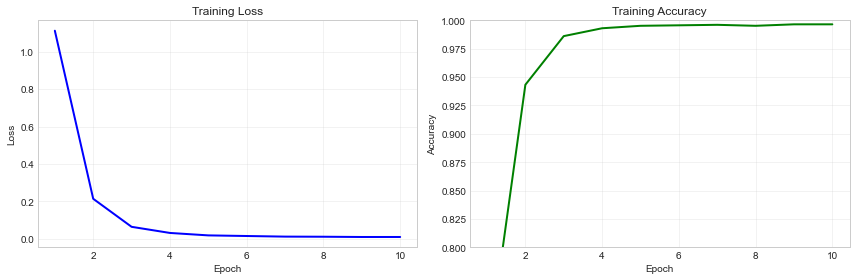

In [17]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(history['loss'])+1), history['loss'], 'b-', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(history['accuracy'])+1), history['accuracy'], 'g-', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.set_ylim([0.8, 1.0])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Evaluate on test set
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs.data, 1)
    y_pred_nn = predicted.cpu().numpy()

acc_nn = accuracy_score(test_data.target, y_pred_nn)
print(f"Neural Network Test Accuracy: {acc_nn:.4f}")
print("\nClassification Report:")
print(classification_report(test_data.target, y_pred_nn, 
                            target_names=test_data.target_names, digits=3))

Neural Network Test Accuracy: 0.9100

Classification Report:
                  precision    recall  f1-score   support

   comp.graphics      0.870     0.888     0.879       384
    misc.forsale      0.945     0.898     0.921       382
rec.sport.hockey      0.947     0.964     0.956       390
       sci.space      0.880     0.889     0.884       378

        accuracy                          0.910      1534
       macro avg      0.910     0.910     0.910      1534
    weighted avg      0.911     0.910     0.910      1534



---
## Part 4: Model Comparison and Analysis

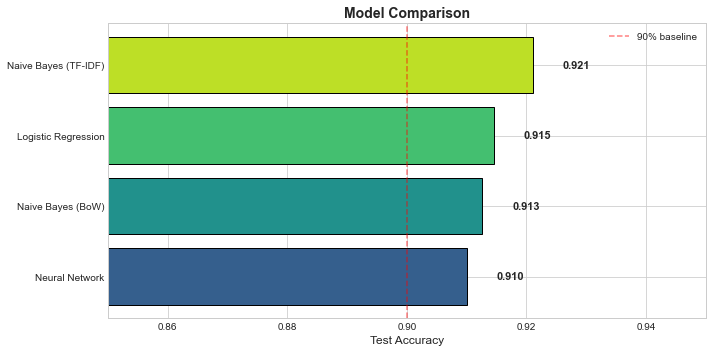


Results Summary:
               Model  Accuracy
      Neural Network  0.910039
   Naive Bayes (BoW)  0.912647
 Logistic Regression  0.914602
Naive Bayes (TF-IDF)  0.921121


In [19]:
# Compare all models
results = pd.DataFrame({
    'Model': [
        'Naive Bayes (BoW)',
        'Naive Bayes (TF-IDF)',
        'Logistic Regression',
        'Neural Network'
    ],
    'Accuracy': [
        acc_nb_bow,
        acc_nb_tfidf,
        acc_lr,
        acc_nn
    ]
}).sort_values('Accuracy', ascending=True)

# Create visualization
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(results)))
bars = ax.barh(results['Model'], results['Accuracy'], color=colors, edgecolor='black')

# Add value labels
for bar, acc in zip(bars, results['Accuracy']):
    ax.text(acc + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{acc:.3f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Test Accuracy', fontsize=12)
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.set_xlim([0.85, 0.95])
ax.axvline(x=0.90, color='red', linestyle='--', alpha=0.5, label='90% baseline')
ax.legend()
plt.tight_layout()
plt.show()

print("\nResults Summary:")
print(results.to_string(index=False))

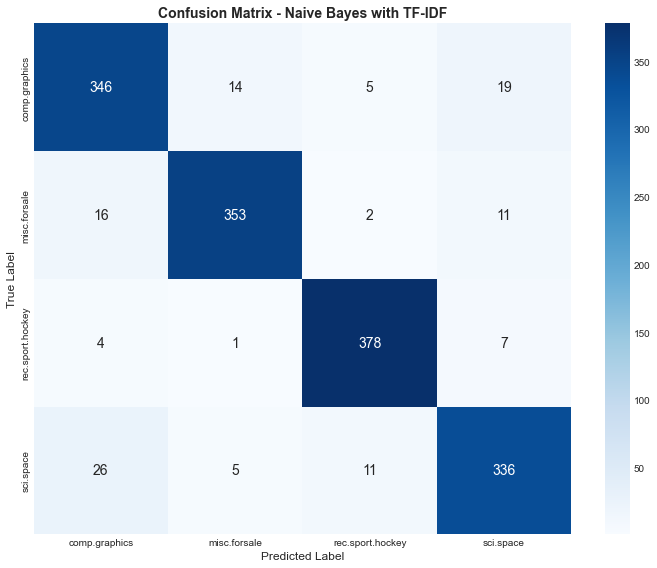


Per-class accuracy:
  comp.graphics: 346/384 = 90.1%
  misc.forsale: 353/382 = 92.4%
  rec.sport.hockey: 378/390 = 96.9%
  sci.space: 336/378 = 88.9%


In [20]:
# Confusion matrix for best model (Naive Bayes with TF-IDF)
cm = confusion_matrix(test_data.target, y_pred_nb_tfidf)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.target_names,
            yticklabels=test_data.target_names,
            ax=ax, annot_kws={'size': 14})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Naive Bayes with TF-IDF', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\nPer-class accuracy:")
for i, name in enumerate(test_data.target_names):
    class_total = cm[i].sum()
    class_correct = cm[i, i]
    print(f"  {name}: {class_correct}/{class_total} = {class_correct/class_total:.1%}")

### Exercise 4: Error Analysis

Let's examine where our logistic regression model makes mistakes. Understanding errors helps improve the model!

In [21]:
def analyze_misclassification(doc_idx, true_label, pred_label, data, vectorizer, classifier):
    """
    Analyze WHY a document was misclassified by examining feature contributions.
    """
    feature_names = vectorizer.get_feature_names_out()
    doc_vector = vectorizer.transform([data.data[doc_idx]]).toarray()[0]
    
    # Get words present in this document
    doc_word_indices = np.nonzero(doc_vector)[0]
    
    # Get classifier weights for true and predicted classes
    true_weights = classifier.coef_[true_label]
    pred_weights = classifier.coef_[pred_label]
    
    # Calculate contribution of each word: tfidf_value * weight
    contributions_to_pred = []
    contributions_to_true = []
    
    for word_idx in doc_word_indices:
        word = feature_names[word_idx]
        tfidf_val = doc_vector[word_idx]
        pred_contrib = tfidf_val * pred_weights[word_idx]
        true_contrib = tfidf_val * true_weights[word_idx]
        
        contributions_to_pred.append((word, pred_contrib, true_contrib))
        contributions_to_true.append((word, true_contrib, pred_contrib))
    
    # Sort by contribution to predicted (wrong) class
    contributions_to_pred.sort(key=lambda x: x[1], reverse=True)
    
    return contributions_to_pred


def show_errors(true_labels, predictions, data, vectorizer, classifier, n=3):
    """
    Show misclassified examples with analysis of WHY they were misclassified.
    """
    errors = np.where(true_labels != predictions)[0]
    print(f"Found {len(errors)} misclassified documents ({len(errors)/len(true_labels):.1%} error rate)\n")
    
    shown = 0
    for idx in errors:
        if shown >= n:
            break
            
        text = data.data[idx].strip()
        if len(text) < 50:  # Skip very short documents
            continue
        
        shown += 1
        true_label = true_labels[idx]
        pred_label = predictions[idx]
        
        print(f"{'='*80}")
        print(f"Error {shown}:")
        print(f"  True label:  {data.target_names[true_label]}")
        print(f"  Predicted:   {data.target_names[pred_label]}")
        
        # Show text preview
        preview = ' '.join(text.split())[:400]
        print(f"\nText preview:")
        print(f"  {preview}...")
        
        # Analyze why it was misclassified
        contributions = analyze_misclassification(
            idx, true_label, pred_label, data, vectorizer, classifier
        )
        
        if contributions:
            print(f"\n  WHY was it classified as '{data.target_names[pred_label]}'?")
            print(f"  Top words pushing toward WRONG class ('{data.target_names[pred_label]}'):")
            for word, pred_contrib, true_contrib in contributions[:5]:
                print(f"    '{word}': +{pred_contrib:.3f} for {data.target_names[pred_label]}, "
                      f"+{true_contrib:.3f} for {data.target_names[true_label]}")
            
            # Show words that would have helped correct classification
            contributions_by_true = sorted(contributions, key=lambda x: x[2], reverse=True)
            print(f"\n  Top words supporting CORRECT class ('{data.target_names[true_label]}'):")
            for word, pred_contrib, true_contrib in contributions_by_true[:5]:
                print(f"    '{word}': +{true_contrib:.3f} for {data.target_names[true_label]}")
        
        print()

show_errors(test_data.target, y_pred_lr, test_data, tfidf_vectorizer, lr, n=3)

Found 131 misclassified documents (8.5% error rate)

Error 1:
  True label:  sci.space
  Predicted:   comp.graphics

Text preview:
  Could someone please help me. I am trying to find the address to the TDRS receiving station at White Sands Missile Range. I am interested in possible employment and would like to write for information....

  WHY was it classified as 'comp.graphics'?
  Top words pushing toward WRONG class ('comp.graphics'):
    'help': +0.304 for comp.graphics, +-0.024 for sci.space
    'write': +0.255 for comp.graphics, +-0.138 for sci.space
    'information': +0.229 for comp.graphics, +-0.026 for sci.space
    'possible': +0.049 for comp.graphics, +0.111 for sci.space
    'trying': +0.014 for comp.graphics, +-0.093 for sci.space

  Top words supporting CORRECT class ('sci.space'):
    'station': +0.181 for sci.space
    'possible': +0.111 for sci.space
    'like': +0.111 for sci.space
    'missile': +0.058 for sci.space
    'range': +0.036 for sci.space

Error 2:
  True 

**Questions to consider:**

1. **Ambiguous vocabulary**: Do any words appear with high weights for *both* the true and predicted class? These ambiguous words make classification harder.

2. **Domain overlap**: Some documents might genuinely contain content from multiple categories (e.g., selling space-related items could overlap `misc.forsale` and `sci.space`).

3. **Possible improvements**:
   - Add bigrams/trigrams to capture phrases like "for sale" or "space shuttle"
   - Use more sophisticated preprocessing (lemmatization, named entity recognition)
   - Try ensemble methods that combine multiple classifiers

---

---
## Part 5: Advanced Analysis - Cross-Validation

So far we've used a single train/test split. But how confident can we be in our results? **Cross-validation** gives us a more robust estimate of model performance.

In [22]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Use 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create pipelines for fair comparison (vectorizer + classifier)
pipelines = {
    'NB + BoW': Pipeline([
        ('vectorizer', CountVectorizer(max_features=5000, min_df=2, max_df=0.8, stop_words='english')),
        ('classifier', MultinomialNB())
    ]),
    'NB + TF-IDF': Pipeline([
        ('vectorizer', TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8, stop_words='english')),
        ('classifier', MultinomialNB())
    ]),
    'LR + TF-IDF': Pipeline([
        ('vectorizer', TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8, stop_words='english')),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])
}

# Run cross-validation
print("Running 5-fold cross-validation...\n")
cv_results = {}
for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, train_data.data, train_data.target, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Scores: {scores.round(4)}")
    print(f"  Mean: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")
    print()

Running 5-fold cross-validation...

NB + BoW:
  Scores: [0.9134 0.9177 0.8983 0.9069 0.8723]
  Mean: 0.9017 (+/- 0.0322)

NB + TF-IDF:
  Scores: [0.9134 0.9286 0.8983 0.9134 0.9004]
  Mean: 0.9108 (+/- 0.0218)

LR + TF-IDF:
  Scores: [0.9242 0.9069 0.8939 0.9113 0.8961]
  Mean: 0.9065 (+/- 0.0220)



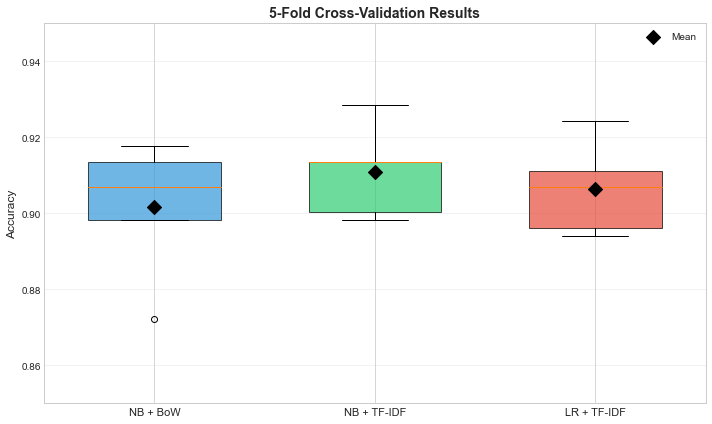

In [23]:
# Visualize cross-validation results
fig, ax = plt.subplots(figsize=(10, 6))

positions = range(len(cv_results))
bp = ax.boxplot([cv_results[name] for name in cv_results.keys()], 
                positions=positions, widths=0.6, patch_artist=True)

# Color the boxes
colors = ['#3498db', '#2ecc71', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(cv_results.keys(), fontsize=11)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
ax.set_ylim([0.85, 0.95])
ax.grid(axis='y', alpha=0.3)

# Add mean markers
means = [cv_results[name].mean() for name in cv_results.keys()]
ax.scatter(positions, means, color='black', s=100, zorder=5, marker='D', label='Mean')
ax.legend()

plt.tight_layout()
plt.show()

---
## Part 6: Advanced Analysis - Learning Curves

How much training data do we actually need? **Learning curves** show how performance changes as we add more training data.

In [24]:
from sklearn.model_selection import learning_curve

# Create the best pipeline
best_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8, stop_words='english')),
    ('classifier', MultinomialNB())
])

# Calculate learning curve
print("Computing learning curve (this may take a minute)...")
train_sizes, train_scores, test_scores = learning_curve(
    best_pipeline, 
    train_data.data, 
    train_data.target,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Calculate mean and std
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

print("Done!")

Computing learning curve (this may take a minute)...
Done!


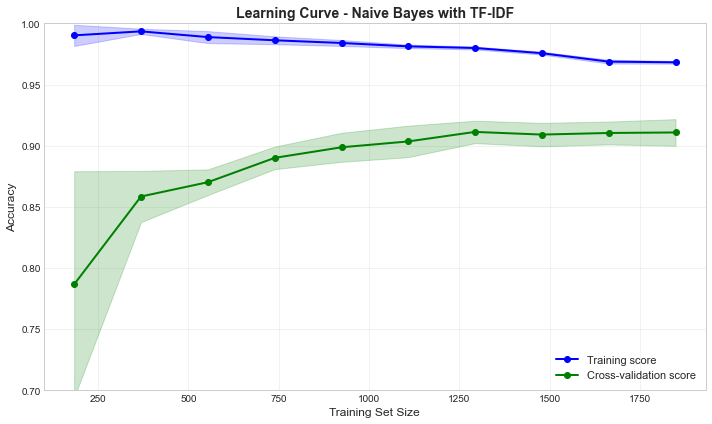


Insights from Learning Curve:
  - With only 554 samples, we achieve 87.0% accuracy
  - Performance plateaus around 1478 samples


In [25]:
# Plot learning curve
fig, ax = plt.subplots(figsize=(10, 6))

# Training score
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score', linewidth=2)

# Cross-validation score
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='green')
ax.plot(train_sizes, test_mean, 'o-', color='green', label='Cross-validation score', linewidth=2)

ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Learning Curve - Naive Bayes with TF-IDF', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim([0.7, 1.0])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInsights from Learning Curve:")
print(f"  - With only {train_sizes[2]:.0f} samples, we achieve {test_mean[2]:.1%} accuracy")
print(f"  - Performance plateaus around {train_sizes[-3]:.0f} samples")

---
## Part 7: Advanced Analysis - Document Embeddings Visualization

Let's visualize how our TF-IDF representations separate the different categories using dimensionality reduction (PCA).

In [26]:
from sklearn.decomposition import IncrementalPCA

# Use PCA for fast visualization
print("Reducing TF-IDF dimensions for visualization...")

# First reduce to 50 dimensions, then to 2
pca_50 = IncrementalPCA(n_components=50)
pca_2 = IncrementalPCA(n_components=2)

X_pca_50 = pca_50.fit_transform(X_train_tfidf.toarray())
X_pca_2 = pca_2.fit_transform(X_pca_50)

print(f"Reduced from {X_train_tfidf.shape[1]} to 2 dimensions")
print(f"Variance explained by 2 components: {pca_2.explained_variance_ratio_.sum():.1%}")

Reducing TF-IDF dimensions for visualization...
Reduced from 5000 to 2 dimensions
Variance explained by 2 components: 10.8%


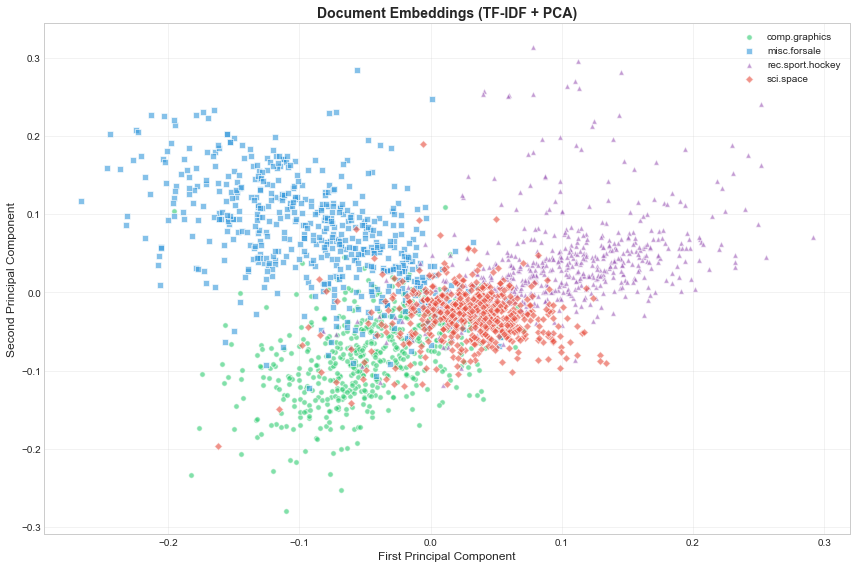


Observations:
  - Categories form distinct clusters in the embedding space
  - Some overlap exists, explaining why we don't get 100% accuracy
  - This visualization only shows 2 dimensions of a high-dimensional space


In [27]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
markers = ['o', 's', '^', 'D']

for i, (color, marker, name) in enumerate(zip(colors, markers, train_data.target_names)):
    mask = train_data.target == i
    ax.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1], 
               c=color, marker=marker, label=name, alpha=0.6, s=30, edgecolors='white')

ax.set_xlabel('First Principal Component', fontsize=12)
ax.set_ylabel('Second Principal Component', fontsize=12)
ax.set_title('Document Embeddings (TF-IDF + PCA)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("  - Categories form distinct clusters in the embedding space")
print("  - Some overlap exists, explaining why we don't get 100% accuracy")
print("  - This visualization only shows 2 dimensions of a high-dimensional space")

---
## Part 8: Advanced Analysis - Word Importance Visualization

Let's create a visualization of the most important words for each category.

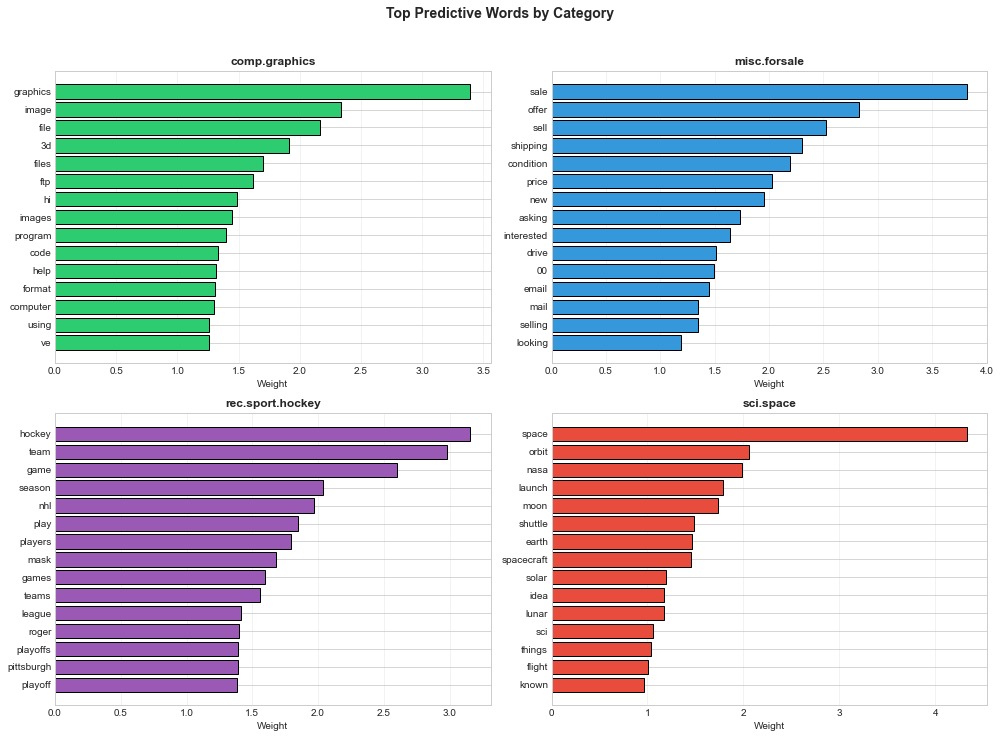

In [28]:
def plot_feature_importance(vectorizer, classifier, class_names, n_top=15):
    """
    Create a visualization of top features for each class.
    """
    feature_names = vectorizer.get_feature_names_out()
    n_classes = len(class_names)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
    
    for i, (ax, name, color) in enumerate(zip(axes, class_names, colors)):
        # Get top features for this class
        weights = classifier.coef_[i]
        top_indices = np.argsort(weights)[-n_top:]
        top_features = [(feature_names[idx], weights[idx]) for idx in top_indices]
        
        words = [f[0] for f in top_features]
        scores = [f[1] for f in top_features]
        
        ax.barh(words, scores, color=color, edgecolor='black')
        ax.set_xlabel('Weight', fontsize=10)
        ax.set_title(f'{name}', fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    plt.suptitle('Top Predictive Words by Category', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_feature_importance(tfidf_vectorizer, lr, train_data.target_names)

---
## Part 9: Class Imbalance (Real-World Challenge)

What happens when some classes have many more examples than others? This is common in real applications!

In [29]:
def create_imbalanced_dataset(X, y, target_names, imbalance_ratio=0.1):
    """
    Create an imbalanced dataset by downsampling some classes.
    """
    indices_to_keep = []
    
    for class_id in range(len(target_names)):
        class_indices = np.where(y == class_id)[0]
        
        if class_id == 0:  # Keep all of first class
            indices_to_keep.extend(class_indices)
        else:  # Downsample others
            n_to_keep = max(int(len(class_indices) * imbalance_ratio), 10)
            sampled = np.random.choice(class_indices, size=n_to_keep, replace=False)
            indices_to_keep.extend(sampled)
    
    return indices_to_keep

# Create imbalanced training set
np.random.seed(42)
imbalanced_indices = create_imbalanced_dataset(
    X_train_tfidf, train_data.target, train_data.target_names
)
X_train_imb = X_train_tfidf[imbalanced_indices]
y_train_imb = train_data.target[imbalanced_indices]

print("Imbalanced class distribution:")
for i, name in enumerate(train_data.target_names):
    count = np.sum(y_train_imb == i)
    pct = count / len(y_train_imb) * 100
    print(f"  {name}: {count} ({pct:.1f}%)")

Imbalanced class distribution:
  comp.graphics: 571 (76.9%)
  misc.forsale: 57 (7.7%)
  rec.sport.hockey: 58 (7.8%)
  sci.space: 57 (7.7%)


In [30]:
# Train on imbalanced data WITHOUT handling imbalance
lr_imb = LogisticRegression(max_iter=1000, random_state=42)
lr_imb.fit(X_train_imb, y_train_imb)
y_pred_imb = lr_imb.predict(X_test_tfidf)

print("Results WITHOUT handling class imbalance:")
print(classification_report(test_data.target, y_pred_imb, 
                            target_names=test_data.target_names, digits=3))

Results WITHOUT handling class imbalance:
                  precision    recall  f1-score   support

   comp.graphics      0.257     1.000     0.409       384
    misc.forsale      1.000     0.018     0.036       382
rec.sport.hockey      1.000     0.082     0.152       390
       sci.space      0.000     0.000     0.000       378

        accuracy                          0.276      1534
       macro avg      0.564     0.275     0.149      1534
    weighted avg      0.568     0.276     0.150      1534



In [31]:
# Train WITH class weight balancing
lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # Automatically adjust for imbalance
    random_state=42
)
lr_balanced.fit(X_train_imb, y_train_imb)
y_pred_balanced = lr_balanced.predict(X_test_tfidf)

print("Results WITH balanced class weights:")
print(classification_report(test_data.target, y_pred_balanced, 
                            target_names=test_data.target_names, digits=3))

print("\nKey takeaway: class_weight='balanced' helps recover minority class performance!")

Results WITH balanced class weights:
                  precision    recall  f1-score   support

   comp.graphics      0.554     0.971     0.706       384
    misc.forsale      0.973     0.746     0.844       382
rec.sport.hockey      0.993     0.774     0.870       390
       sci.space      0.909     0.635     0.748       378

        accuracy                          0.782      1534
       macro avg      0.857     0.782     0.792      1534
    weighted avg      0.858     0.782     0.792      1534


Key takeaway: class_weight='balanced' helps recover minority class performance!


---
## Part 10: Discussion Questions

1. **BoW vs TF-IDF**: When might you prefer one over the other? What are the trade-offs?

2. **Linear vs Neural**: Why didn't the neural network significantly outperform logistic regression? When might you expect neural networks to do better?

3. **Feature Engineering**: How important was feature engineering compared to model choice? What does this tell us about NLP?

4. **Evaluation Metrics**: When might accuracy be a poor metric? What other metrics matter?

5. **Scalability**: Which approach would scale best to millions of documents? Thousands of classes?

6. **Interpretability**: Which models are most interpretable? Why does interpretability matter?